# ANALISIS SENTIMEN KUALITAS LAYANAN APLIKASI MOBILE JKN MENGGUNAKAN ALGORITMA NAIVE BAYES BERBASIS DATA ULASAN GOOGLE PLAY STORE

In [14]:
# Instalasi Library
!pip install wordcloud tabulate Sastrawi -q

# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from IPython.display import display, Markdown

# Konfigurasi Visualisasi agar rapi di GitHub
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 1. Pengumpulan Data Ulasan
Bagian ini menampilkan ringkasan data ulasan yang berhasil dikumpulkan dari Play Store, termasuk periode pengambilan data dan distribusi rating dari pengguna.

Jumlah ulasan berhasil diperoleh: 3000 ulasan
Periode pengambilan data: 4/22/2026 11:08 s/d 6/5/2026 9:51
Jumlah data sebelum seleksi: ~984.000 (berdasarkan data Play Store)
Jumlah data sesudah seleksi & filtering: 3000 ulasan


Tabel Data Hasil Scraping :


,date,score,review
0,6/5/2026 14:03,1,"Daftar autodebet gagal mulu notifnya, padahal ..."
1,6/5/2026 13:40,1,perbaiki dong aplikasinya masa nomor telpon ko...
2,6/5/2026 12:23,5,aplikasi sampah. eror terus harus jaringan 10G...
3,6/5/2026 12:12,5,aplikasi bagus prosesnya cepat dan menunya len...
4,6/5/2026 11:47,5,sangat baik dan bermanfaat sangat lebih cepat ...
...,...,...,...
2995,4/22/2026 13:18,1,"KLO aplikasi tidak terpakai, harus Selalu teru..."
2996,4/22/2026 12:10,1,kenapa yaa apa2 yg berbau pemerintah bawaan ny...
2997,4/22/2026 12:07,5,"kenapa siih aplikasi ini, tiba-tiba Log out,, ..."
2998,4/22/2026 11:47,1,gile dari 2023 coba daftar sampe sekarang masi...


Tabel Distribusi Rating:


,Rating,Jumlah,Persentase
0,1,1714,57.13%
1,2,190,6.33%
2,3,141,4.7%
3,4,88,2.93%
4,5,867,28.9%


/tmp/ipykernel_523/1593375474.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Jumlah', data=rating_dist, palette=colors_rating)


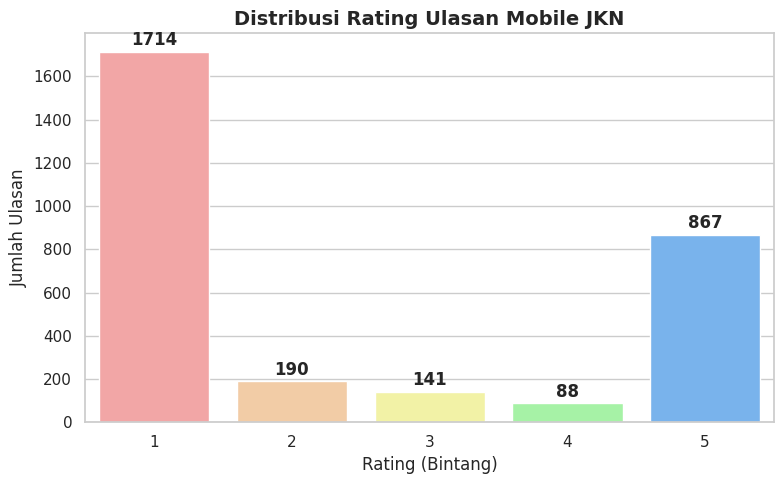

In [15]:
# Load dataset
df = pd.read_csv('/content/ulasan_mobileJKN.csv')

# Pastikan dataframe tidak kosong
assert not df.empty, "Dataset kosong! Periksa path file Anda."

total_data = len(df)
min_date = df['date'].min()
max_date = df['date'].max()


print(f"Jumlah ulasan berhasil diperoleh: {total_data} ulasan")
print(f"Periode pengambilan data: {min_date} s/d {max_date}")
print(f"Jumlah data sebelum seleksi: ~984.000 (berdasarkan data Play Store)")
print(f"Jumlah data sesudah seleksi & filtering: {total_data} ulasan\n")

# Tabel Contoh Data
print("\nTabel Data Hasil Scraping :")
cols_to_show = ['date', 'score', 'review']
if 'label' in df.columns:
    cols_to_show.append('label')
display(df[cols_to_show].head(3000))

# Distribusi Rating
rating_dist = df['score'].value_counts().sort_index().reset_index()
rating_dist.columns = ['Rating', 'Jumlah']
rating_dist['Persentase'] = (rating_dist['Jumlah'] / total_data * 100).round(2).astype(str) + '%'

print("Tabel Distribusi Rating:")
display(rating_dist)

# Visualisasi Distribusi Rating
plt.figure(figsize=(8, 5))
colors_rating = ['#ff9999', '#ffcc99', '#ffff99', '#99ff99', '#66b3ff']
sns.barplot(x='Rating', y='Jumlah', data=rating_dist, palette=colors_rating)
plt.title('Distribusi Rating Ulasan Mobile JKN', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Rating (Bintang)')
plt.xticks(ticks=range(5), labels=[1, 2, 3, 4, 5])
for i, v in enumerate(rating_dist['Jumlah']):
    plt.text(i, v + (total_data * 0.01), str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



## 2. Sebaran Kelas Sentimen
Data ulasan dikategorikan menjadi dua kelas sentimen berdasarkan rating: **Memuaskan** (rating > 3) dan **Tidak Memuaskan** (rating <= 3).

Tabel Distribusi Kelas Sentimen:


,Kelas Sentimen,Jumlah,Persentase
0,Tidak Memuaskan,2045,68.17%
1,Memuaskan,955,31.83%


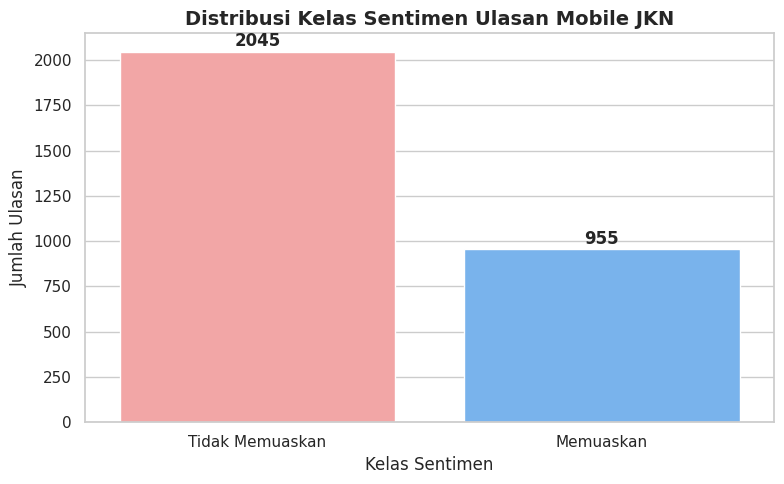

In [16]:
# Labeling berdasarkan score
if 'label' not in df.columns:
    df['label'] = df['score'].apply(lambda x: 'Memuaskan' if x > 3 else 'Tidak Memuaskan')

# Distribusi Kelas Sentimen
dist = df['label'].value_counts().reset_index()
dist.columns = ['Kelas Sentimen', 'Jumlah']
dist['Persentase'] = (dist['Jumlah'] / total_data * 100).round(2).astype(str) + '%'

print("Tabel Distribusi Kelas Sentimen:")
display(dist)

# Visualisasi Sebaran Kelas
plt.figure(figsize=(8, 5))
sns.barplot(x='Kelas Sentimen', y='Jumlah', data=dist, palette=['#ff9999','#66b3ff'], hue='Kelas Sentimen', legend=False)
plt.title('Distribusi Kelas Sentimen Ulasan Mobile JKN', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Ulasan')
plt.xlabel('Kelas Sentimen')
for i, v in enumerate(dist['Jumlah']):
    plt.text(i, v + (total_data * 0.01), str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Tahap Pre-Processing Teks
Teks ulasan diproses melalui beberapa tahapan: *Case Folding*, *Tokenizing*, *Filtering* (dengan mempertahankan kata negasi), dan *Stemming* menggunakan Sastrawi.

In [17]:
# ==========================================================
# PRE-PROCESSING TEKS
# ==========================================================

# Inisialisasi Stopword Remover & Stemmer
factory = StopWordRemoverFactory()
stopword = factory.create_stop_word_remover()
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Kata negasi yang dipertahankan
KATA_NEGASI = ['tidak', 'bukan', 'jangan', 'belum', 'kurang', 'enggak', 'tak', 'bukanlah']
reviews_all = df['review'].astype(str).tolist()

# 1. Case Folding
cf_results_all = [re.sub(r'\s+', ' ', re.sub(r'[^a-z\s]', '', r.lower())).strip() for r in reviews_all]
df['cf_text'] = cf_results_all

# 2. Tokenizing
df['tokenized_text'] = [r.split() for r in df['cf_text']]

# 3. Filtering
filt_results_all = []
for tokens in df['tokenized_text']:
    filtered = [word for word in tokens if stopword.remove(word) != '' or word in KATA_NEGASI]
    filt_results_all.append(filtered)
df['filtered_text'] = filt_results_all

# 4. Stemming
stem_results_all = [[stemmer.stem(word) for word in tokens] for tokens in df['filtered_text']]
df['stemmed_text'] = stem_results_all

# Final Clean Text
df['clean_text'] = df['stemmed_text'].apply(lambda x: ' '.join(x))

# ==========================================================
# TAMPILKAN TABEL PRE-PROCESSING DALAM SATU TABEL HORIZONTAL
# ==========================================================

# Ambil 5 contoh ulasan (prioritas yang panjang > 50 karakter)
sample_df = df[df['review'].str.len() > 50].head(5)
if len(sample_df) < 5:
    sample_df = df.head(5)

# Buat DataFrame horizontal
df_preprocessing = pd.DataFrame({
    'No': [i + 1 for i in range(len(sample_df))],
    'Review Asli': sample_df['review'].astype(str).tolist(),
    'Case Folding': sample_df['cf_text'].astype(str).tolist(),
    'Tokenizing': sample_df['tokenized_text'].apply(str).tolist(),
    'Filtering': sample_df['filtered_text'].apply(str).tolist(),
    'Stemming': sample_df['stemmed_text'].apply(str).tolist()
})
styled_table = df_preprocessing.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'vertical-align': 'top',
    'padding': '10px',
    'border': '1px solid #333333',
    'background-color': '#000000',
    'color': 'white'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#4472C4'), # Changed to blue
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('padding', '10px'),
        ('border', '1px solid #2F5597') # Adjusted border color for contrast
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #333333'),
        ('background-color', '#000000'),
        ('color', 'white')
    ]},
    {'selector': 'tr:nth-child(even)', 'props': [
        ('background-color', '#1a1a1a'),
        ('color', 'white')
    ]}
])



print("📋 Tabel Contoh Proses Pre-Processing Teks")
display(styled_table)


📋 Tabel Contoh Proses Pre-Processing Teks


,No,Review Asli,Case Folding,Tokenizing,Filtering,Stemming
0,1,"Daftar autodebet gagal mulu notifnya, padahal notif sms dari bca berhasil. ini beneran bug atau emang akal-akal oknum bpjs yang kaya dajjal bin maruk duit?",daftar autodebet gagal mulu notifnya padahal notif sms dari bca berhasil ini beneran bug atau emang akalakal oknum bpjs yang kaya dajjal bin maruk duit,"['daftar', 'autodebet', 'gagal', 'mulu', 'notifnya', 'padahal', 'notif', 'sms', 'dari', 'bca', 'berhasil', 'ini', 'beneran', 'bug', 'atau', 'emang', 'akalakal', 'oknum', 'bpjs', 'yang', 'kaya', 'dajjal', 'bin', 'maruk', 'duit']","['daftar', 'autodebet', 'gagal', 'mulu', 'notifnya', 'padahal', 'notif', 'sms', 'bca', 'berhasil', 'beneran', 'bug', 'emang', 'akalakal', 'oknum', 'bpjs', 'kaya', 'dajjal', 'bin', 'maruk', 'duit']","['daftar', 'autodebet', 'gagal', 'mulu', 'notifnya', 'padahal', 'notif', 'sms', 'bca', 'hasil', 'beneran', 'bug', 'emang', 'akalakal', 'oknum', 'bpjs', 'kaya', 'dajjal', 'bin', 'maruk', 'duit']"
1,2,"perbaiki dong aplikasinya masa nomor telpon kode otp nya ga masuk masuk, padahal kuota lancar pakek wifi lancar, nomornya udah benar, penyimpanan masih banyak, masa ga di kasih. anehhh banget bikin kesal",perbaiki dong aplikasinya masa nomor telpon kode otp nya ga masuk masuk padahal kuota lancar pakek wifi lancar nomornya udah benar penyimpanan masih banyak masa ga di kasih anehhh banget bikin kesal,"['perbaiki', 'dong', 'aplikasinya', 'masa', 'nomor', 'telpon', 'kode', 'otp', 'nya', 'ga', 'masuk', 'masuk', 'padahal', 'kuota', 'lancar', 'pakek', 'wifi', 'lancar', 'nomornya', 'udah', 'benar', 'penyimpanan', 'masih', 'banyak', 'masa', 'ga', 'di', 'kasih', 'anehhh', 'banget', 'bikin', 'kesal']","['perbaiki', 'dong', 'aplikasinya', 'masa', 'nomor', 'telpon', 'kode', 'otp', 'nya', 'ga', 'masuk', 'masuk', 'padahal', 'kuota', 'lancar', 'pakek', 'wifi', 'lancar', 'nomornya', 'udah', 'benar', 'penyimpanan', 'banyak', 'masa', 'ga', 'kasih', 'anehhh', 'banget', 'bikin', 'kesal']","['baik', 'dong', 'aplikasi', 'masa', 'nomor', 'telpon', 'kode', 'otp', 'nya', 'ga', 'masuk', 'masuk', 'padahal', 'kuota', 'lancar', 'pakek', 'wifi', 'lancar', 'nomor', 'udah', 'benar', 'simpan', 'banyak', 'masa', 'ga', 'kasih', 'anehhh', 'banget', 'bikin', 'kesal']"
2,3,aplikasi sampah. eror terus harus jaringan 10G baru bisa konek.. aneh sungguh aneh...!!!,aplikasi sampah eror terus harus jaringan g baru bisa konek aneh sungguh aneh,"['aplikasi', 'sampah', 'eror', 'terus', 'harus', 'jaringan', 'g', 'baru', 'bisa', 'konek', 'aneh', 'sungguh', 'aneh']","['aplikasi', 'sampah', 'eror', 'terus', 'jaringan', 'g', 'baru', 'konek', 'aneh', 'sungguh', 'aneh']","['aplikasi', 'sampah', 'eror', 'terus', 'jaring', 'g', 'baru', 'konek', 'aneh', 'sungguh', 'aneh']"
3,4,sangat baik dan bermanfaat sangat lebih cepat pokoknya mantap dahh,sangat baik dan bermanfaat sangat lebih cepat pokoknya mantap dahh,"['sangat', 'baik', 'dan', 'bermanfaat', 'sangat', 'lebih', 'cepat', 'pokoknya', 'mantap', 'dahh']","['sangat', 'baik', 'bermanfaat', 'sangat', 'lebih', 'cepat', 'pokoknya', 'mantap', 'dahh']","['sangat', 'baik', 'manfaat', 'sangat', 'lebih', 'cepat', 'pokok', 'mantap', 'dahh']"
4,5,aplikasi terbaik.. sangat membantu jika ada perubahan apa apa lewat online gampang.. mantap,aplikasi terbaik sangat membantu jika ada perubahan apa apa lewat online gampang mantap,"['aplikasi', 'terbaik', 'sangat', 'membantu', 'jika', 'ada', 'perubahan', 'apa', 'apa', 'lewat', 'online', 'gampang', 'mantap']","['aplikasi', 'terbaik', 'sangat', 'membantu', 'perubahan', 'apa', 'apa', 'lewat', 'online', 'gampang', 'mantap']","['aplikasi', 'baik', 'sangat', 'bantu', 'ubah', 'apa', 'apa', 'lewat', 'online', 'gampang', 'mantap']"


## 4. Ekstraksi Fitur TF-IDF
Setelah teks dibersihkan, tahap selanjutnya adalah mengubah teks menjadi representasi numerik menggunakan **TF-IDF (Term Frequency-Inverse Document Frequency)**. Metode ini memberikan bobot lebih tinggi pada kata yang sering muncul di satu dokumen tetapi jarang muncul di dokumen lain, sehingga kata-kata penting dapat teridentifikasi.

In [18]:

# ==========================================================
# HASIL TF-IDF
# ==========================================================

# Pastikan tfidf sudah di-fit (dari cell evaluasi sebelumnya)
# Jika belum, fit ulang
if 'tfidf' not in dir() or not hasattr(tfidf, 'vocabulary_'):
    X_train, X_test, y_train, y_test = train_test_split(
        df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label']
    )
    tfidf = TfidfVectorizer(max_features=5000)
    tfidf.fit(X_train)

# Ambil 5 sampel data yang SAMA dengan pre-processing
sample_df = df[df['review'].str.len() > 50].head(5)
if len(sample_df) < 5:
    sample_df = df.head(5)

# Transform data sampel ke TF-IDF
tfidf_matrix = tfidf.transform(sample_df['clean_text'])
tfidf_array = tfidf_matrix.toarray()
feature_names = tfidf.get_feature_names_out()

# Ambil TOP 8 kata dengan rata-rata bobot TF-IDF tertinggi
mean_tfidf = tfidf_array.mean(axis=0)
top_indices = mean_tfidf.argsort()[::-1][:8]
top_keywords = feature_names[top_indices]

# Buat DataFrame untuk 5 sampel dengan top 8 kata
df_tfidf = pd.DataFrame({
    'Dokumen': [f"Dokumen {i + 1}" for i in range(len(sample_df))]
})

# Tambahkan kolom untuk setiap top keyword
for i, keyword in enumerate(top_keywords):
    df_tfidf[keyword] = [f"{val:.3f}" if val > 0 else '0.00'
                         for val in tfidf_array[:, top_indices[i]]]

# ==========================================================
# STYLING TABEL TF-IDF (LATAR BELAKANG GELAP)
# ==========================================================

def highlight_tfidf(val):
    """Memberikan warna berdasarkan nilai TF-IDF untuk latar belakang gelap"""
    if val == '-' or val == '':
        return 'background-color: #343a40; color: #adb5bd' # Dark gray background, light gray text
    try:
        v = float(val)
        if v == 0:
            return 'background-color: #343a40; color: #adb5bd'
        elif v < 0.2:
            return 'background-color: #001a33; color: #66b3ff'  # Very dark blue, light blue text
        elif v < 0.4:
            return 'background-color: #003366; color: #b8daff'  # Dark blue, medium blue text
        elif v < 0.6:
            return 'background-color: #004c99; color: white'    # Darker blue, white text
        else:
            return 'background-color: #0066cc; color: white'    # Bright blue, white text
    except:
        return ''

styled_tfidf = df_tfidf.style.set_properties(**{
    'text-align': 'center',
    'vertical-align': 'middle',
    'padding': '8px',
    'background-color': '#000000', # Black background
    'color': 'white',
    'border': '1px solid #333333',
    'font-size': '11px'
}).set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#4472C4'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('text-align', 'center'),
        ('padding', '10px 8px'),
        ('border', '1px solid #2F5597'),
        ('font-size', '11px')
    ]},
    {'selector': 'td', 'props': [
        ('border', '1px solid #333333')
    ]},
    {'selector': 'tr:nth-child(even) td', 'props': [
        ('background-color', '#1a1a1a') # Dark gray for alternating rows
    ]}
]).map(
    highlight_tfidf,
    subset=[col for col in df_tfidf.columns if col not in ['Dokumen']]
)

print("📊 Tabel Nilai TF-IDF ")
print("💡 Keterangan: Warna semakin gelap = bobot TF-IDF semakin tinggi (kata semakin penting)")
display(styled_tfidf)

📊 Tabel Nilai TF-IDF 
💡 Keterangan: Warna semakin gelap = bobot TF-IDF semakin tinggi (kata semakin penting)


,Dokumen,mantap,sangat,aneh,baik,apa,dahh,konek,pokok
0,Dokumen 1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,Dokumen 2,0.00,0.00,0.00,0.117,0.00,0.00,0.00,0.00
2,Dokumen 3,0.00,0.00,0.551,0.00,0.00,0.00,0.468,0.00
3,Dokumen 4,0.354,0.386,0.00,0.203,0.00,0.489,0.00,0.427
4,Dokumen 5,0.386,0.211,0.00,0.221,0.494,0.00,0.00,0.00


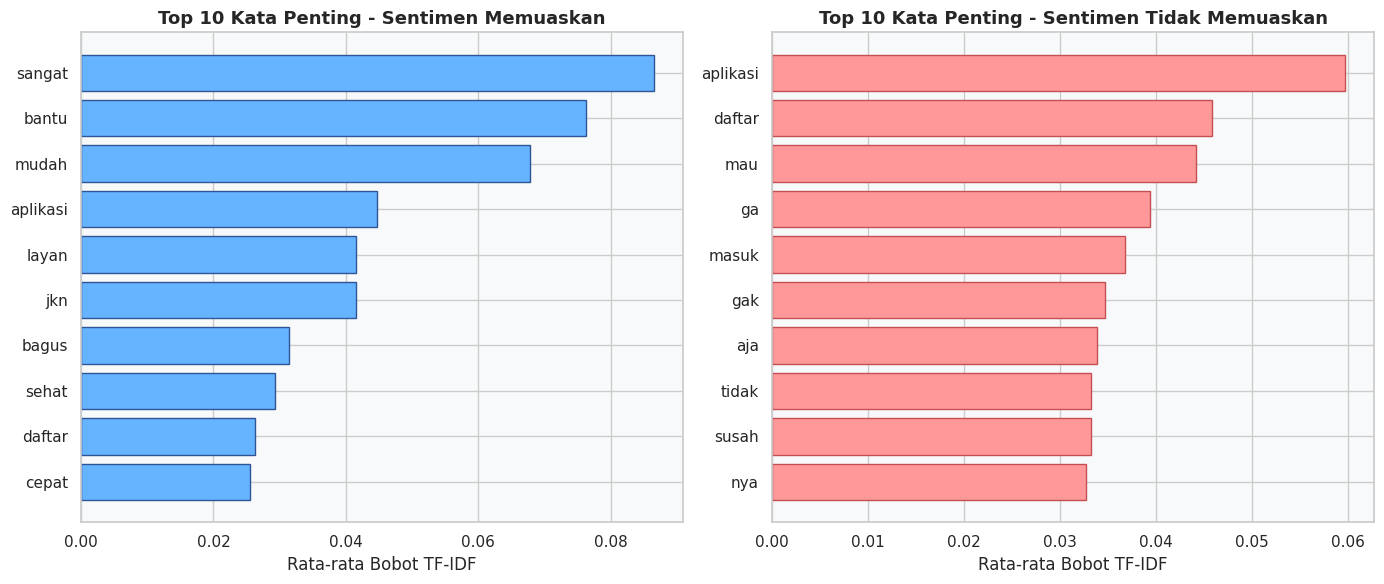


💡 INSIGHT TF-IDF:
→ Kata-kata yang paling membedakan ulasan MEMUASKAN: sangat, bantu, mudah, aplikasi, layan
→ Kata-kata yang paling membedakan ulasan TIDAK MEMUASKAN: aplikasi, daftar, mau, ga, masuk
→ Kata-kata ini memiliki bobot TF-IDF tinggi karena sering muncul di satu kelas tetapi jarang di kelas lain.


In [19]:
# ==========================================================
# VISUALISASI TOP KATA TF-IDF SECARA KESELURUHAN
# ==========================================================

# Hitung rata-rata bobot TF-IDF untuk SEMUA data per kelas
tfidf_all = tfidf.transform(df['clean_text']).toarray()

# Rata-rata untuk kelas Memuaskan
df_pos = df[df['label'] == 'Memuasan'] if 'Memuasan' in df['label'].values else df[df['label'] == 'Memuaskan']
df_neg = df[df['label'] == 'Tidak Memuaskan']

tfidf_pos = tfidf.transform(df_pos['clean_text']).toarray().mean(axis=0)
tfidf_neg = tfidf.transform(df_neg['clean_text']).toarray().mean(axis=0)

# Ambil top 10 kata per kelas
top_pos_idx = tfidf_pos.argsort()[::-1][:10]
top_neg_idx = tfidf_neg.argsort()[::-1][:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot Sentimen Memuaskan
words_pos = [feature_names[i] for i in top_pos_idx]
scores_pos = [tfidf_pos[i] for i in top_pos_idx]
axes[0].barh(words_pos[::-1], scores_pos[::-1], color='#66b3ff', edgecolor='#2F5597')
axes[0].set_title('Top 10 Kata Penting - Sentimen Memuaskan', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Rata-rata Bobot TF-IDF')
axes[0].set_facecolor('#f8f9fa')

# Plot Sentimen Tidak Memuaskan
words_neg = [feature_names[i] for i in top_neg_idx]
scores_neg = [tfidf_neg[i] for i in top_neg_idx]
axes[1].barh(words_neg[::-1], scores_neg[::-1], color='#ff9999', edgecolor='#c44e52')
axes[1].set_title('Top 10 Kata Penting - Sentimen Tidak Memuaskan', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rata-rata Bobot TF-IDF')
axes[1].set_facecolor('#f8f9fa')

plt.tight_layout()
plt.show()

# Tampilkan insight
print("\n💡 INSIGHT TF-IDF:")
print(f"→ Kata-kata yang paling membedakan ulasan MEMUASKAN: {', '.join(words_pos[:5])}")
print(f"→ Kata-kata yang paling membedakan ulasan TIDAK MEMUASKAN: {', '.join(words_neg[:5])}")
print("→ Kata-kata ini memiliki bobot TF-IDF tinggi karena sering muncul di satu kelas tetapi jarang di kelas lain.")

## 5. Perhitungan Manual Naïve Bayes
Bagian ini mendemonstrasikan perhitungan manual klasifikasi Naïve Bayes untuk satu kalimat uji, meliputi Probabilitas Prior, Likelihood dengan Laplace Smoothing, dan Posterior.

In [20]:
# Penentuan Data Contoh
kalimat_uji = "otp tidak masuk"
print(f"Kalimat Uji: '{kalimat_uji}'\n")

# Preprocess kalimat uji
kalimat_cf = kalimat_uji.lower()
kalimat_token = kalimat_cf.split()
stopword_manual = ['dan', 'yang', 'di', 'ke', 'dari', 'untuk', 'dengan', 'ini', 'itu']
kalimat_stem = [w for w in kalimat_token if w not in stopword_manual]
print(f"Token setelah preprocessing: {kalimat_stem}\n")

# Probabilitas Prior
total_memuaskan = len(df[df['label'] == 'Memuaskan'])
total_tidak = len(df[df['label'] == 'Tidak Memuaskan'])
total_semua = len(df)
prior_memuaskan = total_memuaskan / total_semua
prior_tidak = total_tidak / total_semua

print("Perhitungan Probabilitas Prior:")
print(f"P(Memuaskan) = {total_memuaskan} / {total_semua} = {prior_memuaskan:.4f}")
print(f"P(Tidak Memuaskan) = {total_tidak} / {total_semua} = {prior_tidak:.4f}\n")
display(pd.DataFrame({
    'Kelas': ['Memuaskan', 'Tidak Memuaskan'],
    'Jumlah Data': [total_memuaskan, total_tidak],
    'Probabilitas Prior P(c)': [f"{prior_memuaskan:.4f}", f"{prior_tidak:.4f}"]
}))

# Likelihood & Laplace Smoothing
vectorizer_manual = CountVectorizer()
X_counts = vectorizer_manual.fit_transform(df['clean_text'])
vocab = vectorizer_manual.get_feature_names_out()
V = len(vocab)

df_memuaskan = df[df['label'] == 'Memuaskan']
df_tidak = df[df['label'] == 'Tidak Memuaskan']
X_memuaskan = vectorizer_manual.transform(df_memuaskan['clean_text'])
X_tidak = vectorizer_manual.transform(df_tidak['clean_text'])
N_c_memuaskan = X_memuaskan.sum()
N_c_tidak = X_tidak.sum()

print(f"\nPerhitungan Likelihood (Laplace Smoothing, α=1)")
print(f"Ukuran Kosakata (|V|) = {V} | Total kata Memuaskan = {N_c_memuaskan} | Total kata Tidak = {N_c_tidak}\n")

hasil_likelihood = []
for kata in kalimat_stem:
    idx_kata = list(vocab).index(kata) if kata in vocab else -1
    count_m = X_memuaskan[:, idx_kata].sum() if idx_kata != -1 else 0
    count_t = X_tidak[:, idx_kata].sum() if idx_kata != -1 else 0

    prob_m = (count_m + 1) / (N_c_memuaskan + V)
    prob_t = (count_t + 1) / (N_c_tidak + V)

    hasil_likelihood.append({
        'Kata': kata, 'Count Memuaskan': count_m, 'Count Tidak': count_t,
        'P(w_i | Memuaskan)': f"{prob_m:.6f}", 'P(w_i | Tidak)': f"{prob_t:.6f}"
    })

print("Tabel Likelihood & Laplace Smoothing:")
display(pd.DataFrame(hasil_likelihood))

# Perhitungan Posterior
prob_post_m = prior_memuaskan
prob_post_t = prior_tidak
for item in hasil_likelihood:
    prob_post_m *= float(item['P(w_i | Memuaskan)'])
    prob_post_t *= float(item['P(w_i | Tidak)'])

print("\nPerhitungan Posterior dan Hasil Klasifikasi:")
print(f"P(Memuaskan | d) = {prior_memuaskan:.4f} x {' x '.join([item['P(w_i | Memuaskan)'] for item in hasil_likelihood])} = {prob_post_m:.10f}")
print(f"P(Tidak Memuaskan | d) = {prior_tidak:.4f} x {' x '.join([item['P(w_i | Tidak)'] for item in hasil_likelihood])} = {prob_post_t:.10f}")

kelas_prediksi = "Memuaskan" if prob_post_m > prob_post_t else "Tidak Memuaskan"
print(f"\n✅ HASIL KLASIFIKASI: Kalimat '{kalimat_uji}' diklasifikasikan sebagai sentimen [{kelas_prediksi}]")

Kalimat Uji: 'otp tidak masuk'

Token setelah preprocessing: ['otp', 'tidak', 'masuk']

Perhitungan Probabilitas Prior:
P(Memuaskan) = 955 / 3000 = 0.3183
P(Tidak Memuaskan) = 2045 / 3000 = 0.6817



,Kelas,Jumlah Data,Probabilitas Prior P(c)
0,Memuaskan,955,0.3183
1,Tidak Memuaskan,2045,0.6817



Perhitungan Likelihood (Laplace Smoothing, α=1)
Ukuran Kosakata (|V|) = 4552 | Total kata Memuaskan = 11478 | Total kata Tidak = 36197

Tabel Likelihood & Laplace Smoothing:


,Kata,Count Memuaskan,Count Tidak,P(w_i | Memuaskan),P(w_i | Tidak)
0,otp,50,401,0.003182,0.009865
1,tidak,102,444,0.006425,0.010921
2,masuk,95,509,0.005989,0.012516



Perhitungan Posterior dan Hasil Klasifikasi:
P(Memuaskan | d) = 0.3183 x 0.003182 x 0.006425 x 0.005989 = 0.0000000390
P(Tidak Memuaskan | d) = 0.6817 x 0.009865 x 0.010921 x 0.012516 = 0.0000009192

✅ HASIL KLASIFIKASI: Kalimat 'otp tidak masuk' diklasifikasikan sebagai sentimen [Tidak Memuaskan]


## 6. Evaluasi Performa Model
Model Naïve Bayes dievaluasi menggunakan metrik *Accuracy*, *Precision*, *Recall*, dan *F1-Score* dengan pembagian data *train-test split* 80:20.

Hasil Confusion Matrix:
TN: 407 | FP: 2 | FN: 88 | TP: 103



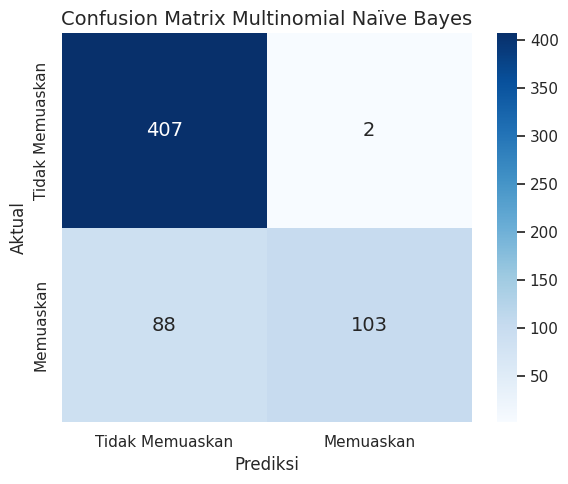

Hasil Pengukuran Metrik Evaluasi:
1. Accuracy  : 0.8500 (85.00%)
2. Precision : 0.8728 (87.28%)
3. Recall    : 0.8500 (85.00%)
4. F1-Score  : 0.8353 (83.53%)


In [21]:
# Data Splitting & TF-IDF
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Training & Prediksi
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
y_pred = model_nb.predict(X_test_tfidf)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Tidak Memuaskan', 'Memuaskan'])
tn, fp, fn, tp = cm.ravel()
print("Hasil Confusion Matrix:")
print(f"TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}\n")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Memuaskan', 'Memuaskan'], yticklabels=['Tidak Memuaskan', 'Memuaskan'], annot_kws={"size": 14})
plt.ylabel('Aktual', fontsize=12); plt.xlabel('Prediksi', fontsize=12)
plt.title('Confusion Matrix Multinomial Naïve Bayes', fontsize=14)
plt.tight_layout()
plt.show()

# Metrik Evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Hasil Pengukuran Metrik Evaluasi:")
print(f"1. Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"2. Precision : {prec:.4f} ({prec*100:.2f}%)")
print(f"3. Recall    : {rec:.4f} ({rec*100:.2f}%)")
print(f"4. F1-Score  : {f1:.4f} ({f1*100:.2f}%)")

In [22]:
interpretasi_md = f"""
> **Interpretasi Metrik Evaluasi:**
> - **Accuracy** sebesar **{acc*100:.2f}%** menunjukkan tingkat ketepatan keseluruhan model.
> - **Precision** **{prec*100:.2f}%** menunjukkan dari semua ulasan yang diprediksi sebagai suatu kelas, persentase tersebut benar.
> - **Recall** **{rec*100:.2f}%** menunjukkan kemampuan model dalam menemukan semua data yang sebenarnya termasuk dalam kelas tersebut.
> - **F1-Score** **{f1*100:.2f}%** menunjukkan keseimbangan yang baik antara Precision dan Recall.
"""
display(Markdown(interpretasi_md))


> **Interpretasi Metrik Evaluasi:**
> - **Accuracy** sebesar **85.00%** menunjukkan tingkat ketepatan keseluruhan model.
> - **Precision** **87.28%** menunjukkan dari semua ulasan yang diprediksi sebagai suatu kelas, persentase tersebut benar.
> - **Recall** **85.00%** menunjukkan kemampuan model dalam menemukan semua data yang sebenarnya termasuk dalam kelas tersebut.
> - **F1-Score** **83.53%** menunjukkan keseimbangan yang baik antara Precision dan Recall.


## 7.  Pembahasan dan Analisis Dimensi E-ServQual
Analisis ini memetakan kata kunci dari ulasan negatif ke dalam dimensi kualitas layanan elektronik (E-ServQual) untuk mengetahui aspek apa yang paling perlu diperbaiki.

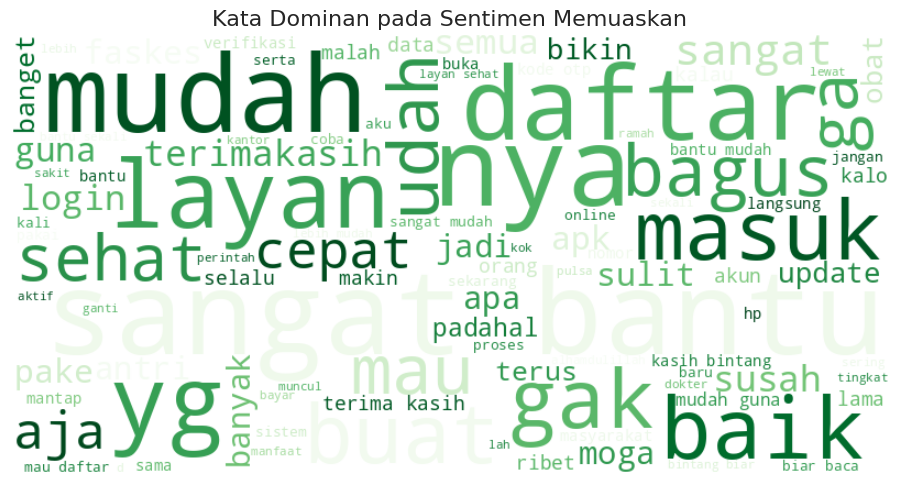

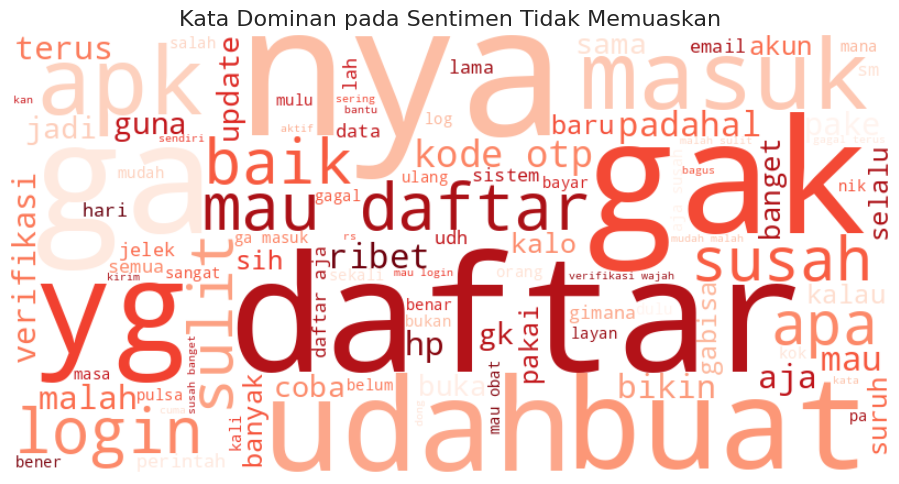

Tabel Pemetaan Dimensi E-ServQual (Berdasarkan Ulasan Negatif):


,Dimensi E-ServQual,Kata Kunci,Total Penyebutan,Kata Dominan
0,Efficiency,"cepat, lambat, lemot, sulit, mudah, praktis, antre, antri",692,sulit (338x)
1,Fulfillment,"gagal, sukses, fitur, manfaat, bantu, guna, sesuai, rujuk",458,gagal (170x)
3,Privacy,"data, pribadi, aman, bocor, password, sand, nik, nomor",411,nomor (168x)
2,System Availability,"error, bug, down, offline, server, gangguan, macet, keluar, logout",301,keluar (85x)
4,Usability,"mudah dipahami, navigasi, ribet, membingungkan, menu, tampilan, antarmuka, susah dipahami, user friendly",263,ribet (255x)


In [23]:
# Gabungkan teks untuk Word Cloud
text_positif = " ".join(review for review in df[df['label'] == 'Memuaskan']['clean_text'])
text_negatif = " ".join(review for review in df[df['label'] == 'Tidak Memuaskan']['clean_text'])

# PERBAIKAN BUG: set.update() mengembalikan None, harus dipisah
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['aplikasi', 'mobile', 'jkn', 'bpjs', 'saya', 'yang', 'dan', 'di', 'ke', 'untuk', 'dengan', 'ini', 'itu', 'ada', 'juga', 'bisa', 'tidak'])

# Word Cloud
for label, text, cmap, title in [('Memuaskan', text_positif, 'Greens', 'Sentimen Memuaskan'),
                                 ('Tidak Memuaskan', text_negatif, 'Reds', 'Sentimen Tidak Memuaskan')]:
    wc = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap=cmap, stopwords=custom_stopwords).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(f'Kata Dominan pada {title}', fontsize=16)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Pemetaan E-ServQual
dimensi_keywords = {
    'Efficiency': ['cepat', 'lambat', 'lemot', 'sulit', 'mudah', 'praktis', 'antre', 'antri'],
    'Fulfillment': ['gagal', 'sukses', 'fitur', 'manfaat', 'bantu', 'guna', 'sesuai', 'rujuk'],
    'System Availability': ['error', 'bug', 'down', 'offline', 'server', 'gangguan', 'macet', 'keluar', 'logout'],
    'Privacy': ['data', 'pribadi', 'aman', 'bocor', 'password', 'sand', 'nik', 'nomor'],
    'Usability': ['mudah dipahami', 'navigasi', 'ribet', 'membingungkan', 'menu', 'tampilan', 'antarmuka', 'susah dipahami', 'user friendly']
}

hasil_pemetaan = []
for dimensi, keywords in dimensi_keywords.items():
    total_kejadian, kata_terbanyak, max_count = 0, "", 0
    for kw in keywords:
        count = df[df['label'] == 'Tidak Memuaskan']['clean_text'].str.contains(rf'\b{kw}\b', case=False, na=False).sum()
        total_kejadian += count
        if count > max_count: max_count, kata_terbanyak = count, kw

    hasil_pemetaan.append({
        'Dimensi E-ServQual': dimensi, 'Kata Kunci': ', '.join(keywords),
        'Total Penyebutan': total_kejadian, 'Kata Dominan': f"{kata_terbanyak} ({max_count}x)"
    })

df_dimensi = pd.DataFrame(hasil_pemetaan).sort_values(by='Total Penyebutan', ascending=False)
print("Tabel Pemetaan Dimensi E-ServQual (Berdasarkan Ulasan Negatif):")
display(df_dimensi.style.set_properties(**{'text-align': 'left'}))

In [24]:
dimensi_teratas = df_dimensi.iloc[0]['Dimensi E-ServQual']

analisis_md = f"""
> **Analisis dan Rekomendasi:**
> 1. Berdasarkan tabel di atas, dimensi yang paling banyak memperoleh keluhan adalah **{dimensi_teratas}**.
> 2. Hal ini menunjukkan bahwa pengguna Mobile JKN paling kecewa terhadap aspek tersebut (misal: sistem yang sering error/logout atau proses yang lambat).
> 3. **Rekomendasi:** Pengembang Mobile JKN perlu memprioritaskan perbaikan pada infrastruktur server untuk mengurangi 'error' dan 'logout' mendadak, serta menyederhanakan alur registrasi agar tidak 'ribet' atau 'sulit', terutama bagi pengguna lansia.
"""
display(Markdown(analisis_md))


> **Analisis dan Rekomendasi:**
> 1. Berdasarkan tabel di atas, dimensi yang paling banyak memperoleh keluhan adalah **Efficiency**.
> 2. Hal ini menunjukkan bahwa pengguna Mobile JKN paling kecewa terhadap aspek tersebut (misal: sistem yang sering error/logout atau proses yang lambat).
> 3. **Rekomendasi:** Pengembang Mobile JKN perlu memprioritaskan perbaikan pada infrastruktur server untuk mengurangi 'error' dan 'logout' mendadak, serta menyederhanakan alur registrasi agar tidak 'ribet' atau 'sulit', terutama bagi pengguna lansia.
